# Coverage gain of the CGFS greedy sequence

Records the weighted coverage $\mathcal{G}(F_i)$ after each greedy step
$i = 1 \dots 25$, for the three IoT datasets, averaged over three seeds.

The CGFS greedy already returns the trace it needs: `cgfs(sim, w, k)` yields
`errors[i-1]` $= E_i = d - \sum_j w_j g_j$, so $\mathcal{G}(F_i) = d - E_i$
requires no extra computation. This notebook runs the selection once per dataset
per seed and reads the trajectory off that run.

## One methodological point before the numbers

$\mathcal{G}$ is bounded above by $\sum_j w_j = d$, because selecting every
feature drives each $g_j$ to $s(f_j, f_j) = 1$. The maximum attainable coverage
is therefore the screened dimensionality itself, which differs across the three
datasets (77, 35, and 34 in the runs reported in the paper). **Averaging the raw
$\mathcal{G}(F_i)$ across datasets is therefore not meaningful**: the mean would
be dominated by whichever dataset happens to have the most columns, and a curve
that rose to 66 would say nothing except that one dataset has 77 features.

Two quantities are reported instead, and both are exact rather than conventions
adopted for convenience:

* $\mathcal{G}(F_i)$ **per dataset**, on its own axis. This is the quantity the
  algorithm maximises and the one that appears in the bounds.
* $\mathcal{G}(F_i)/d$, the **fraction of attainable coverage**. Since $d$ is the
  exact supremum of $\mathcal{G}$, this is a normalisation by the optimum rather
  than by an arbitrary scale, it lies in $[0,1]$ on every dataset, and it is the
  quantity whose cross-dataset average is well defined.

The marginal gains $\Delta_i = \mathcal{G}(F_i) - \mathcal{G}(F_{i-1})$ are
reported alongside, since their monotone decrease is the empirical signature of
the submodularity the analysis assumes.

Set `DATA_DIR` in the config cell and run top to bottom. `faiss` is optional; the
notebook falls back to an exact NumPy/BLAS equivalent.

## 1. Configuration

In [1]:
# ---------------------------------------------------------------- config ----
DATA_DIR = "."                   # DatasetSpec paths below are relative to this
OUT_DIR  = "."

DATASETS_TO_RUN = ["rt-iot", "edge-iiot", "cic-iot"]
SEEDS  = [0, 1, 2]
KMAX   = 25                      # greedy steps to trace

TEST_SIZE = 0.30                 # the split is kept so that screening and the
                                 # weights are estimated on the training partition,
                                 # exactly as in the main experiments
MI_BINS           = 32
NEAR_CONST_THRESH = 0.995
SCREEN            = True
DROP_LEAKY        = True

# Same per-class base sample as the rest of the paper, so the CICIoT2023
# trajectory refers to the same population as its reported results.
BASE_SAMPLE = {
    "cic-iot": {"frac": 1 / 7, "random_state": 42},
}

# Also trace the unweighted objective (w = 1) for comparison. Costs nothing extra:
# the similarity matrix is already built.
INCLUDE_UNWEIGHTED = True

# Minoux's data-dependent bound on the optimum (Section 7). One extra pass of d
# marginal-gain evaluations per run.
COMPUTE_ONLINE_BOUND = True

VERBOSE = True

## 2. Imports

In [2]:
import heapq, time, warnings, os
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

try:
    import faiss
    HAVE_FAISS = True
except ImportError:
    HAVE_FAISS = False

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {matplotlib.__version__}")
print(f"faiss: {'yes' if HAVE_FAISS else 'NO  -> exact NumPy/BLAS fallback (identical similarities)'}")

numpy 1.26.4 | pandas 2.1.4 | matplotlib 3.8.2
faiss: yes


## 3. Dataset specs and preprocessing

In [3]:
@dataclass(frozen=True)
class DatasetSpec:
    name: str
    path: str
    target: str
    drop: list
    # Columns that identify hosts/sessions or are raw payload/timestamps.
    leaky: list = field(default_factory=list)


DATASETS = {
    "rt-iot": DatasetSpec(
        name="RT-IoT2022",
        path="../RT_IOT2022.csv",
        target="Attack_type",
        drop=["Unnamed: 0", "Attack_type", "Attack_Label"],
        leaky=[],
    ),
    "edge-iiot": DatasetSpec(
        name="Edge-IIoTset",
        path="../ML-EdgeIIoT-dataset.csv",
        target="Attack_type",
        drop=["Attack_label", "Attack_type"],
        leaky=[
            "frame.time", "ip.src_host", "ip.dst_host",
            "arp.src.proto_ipv4", "arp.dst.proto_ipv4",
            "http.request.full_uri", "http.file_data", "http.request.uri.query",
            "tcp.payload", "tcp.options", "mqtt.msg", "dns.qry.name",
        ],
    ),
        "cic-iot": DatasetSpec(
        name="CICIoT2023",
        path="../CICIoT2023.csv",
        target="label",
        drop=['label', 'Binary Label'],
        leaky=[
        ],
    ),
}


def apply_base_sample(df, col, frac, random_state):
    """Per-class fraction, equivalent to

        df.groupby(col, group_keys=False).apply(lambda x: x.sample(frac, random_state))

    written without .apply because pandas 3.0 stops passing the grouping column
    through to the function, which would drop the label column outright. Group
    order and the rows chosen within each group are identical: groupby sorts its
    keys, and each group gets a fresh RandomState(random_state), exactly as the
    .apply form does.
    """
    parts = [g.sample(frac=frac, random_state=random_state)
             for _, g in df.groupby(col, sort=True)]
    out = pd.concat(parts)
    print(f"  base sample: {len(df):,} -> {len(out):,} rows "
          f"(per-class frac={frac:.4g}, random_state={random_state})")
    return out


def load_dataset(spec: DatasetSpec, drop_leaky: bool, base_sample=None):
    """Read the CSV, drop target/leaky columns, integer-encode the rest."""
    path = os.path.join(DATA_DIR, spec.path)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Could not find '{path}'. Set DATA_DIR (and DATASET_KEY) in the config cell.")
    df = pd.read_csv(path, low_memory=False)
    if base_sample:
        df = apply_base_sample(df, spec.target, base_sample["frac"],
                               base_sample["random_state"])
    
    y = df[spec.target].values
    X = df.drop([c for c in spec.drop if c in df.columns], axis=1)
    if drop_leaky:
        dropped_leaky = [c for c in spec.leaky if c in X.columns]
        X = X.drop(dropped_leaky, axis=1)
    else:
        dropped_leaky = []

    # Test numeric-ness rather than `dtype == 'object'`: on pandas >= 3.0 text
    # columns carry the dedicated 'str' dtype, so the older check silently skips
    # them and the string values reach the similarity computation unencoded.
    encoded = []
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))
            encoded.append(col)

    X = X.replace([np.inf, -np.inf], np.nan)
    n_filled = int(X.isna().to_numpy().sum())
    X = X.fillna(0)

    print(f"{spec.name}: {X.shape[0]:,} rows x {X.shape[1]} columns "
          f"({'leaky columns dropped: ' + str(dropped_leaky) if drop_leaky else 'LEAKY COLUMNS KEPT'})")
    print(f"  label-encoded columns : {encoded if encoded else 'none'}")
    print(f"  non-finite/missing cells filled with 0 : {n_filled:,}")
    return X.values.astype(np.float64), y, list(X.columns)

## 4. Screening and standardisation

In [4]:
def screen_columns(Xtr: np.ndarray, cols: list, enabled: bool,
                   near_const_thresh):
    """Indices of columns kept after constant / near-constant screening."""
    if not enabled:
        return list(range(Xtr.shape[1])), list(cols)
    keep = []
    n = len(Xtr)
    for j in range(Xtr.shape[1]):
        col = Xtr[:, j]
        if len(np.unique(col)) <= 1:
            continue
        if near_const_thresh is not None:
            _, counts = np.unique(col, return_counts=True)
            if counts.max() / n >= near_const_thresh:
                continue
        keep.append(j)
    return keep, [cols[j] for j in keep]


def zscore(Xtr: np.ndarray, Xte: np.ndarray):
    """Standardize with training statistics only."""
    mu = Xtr.mean(axis=0)
    sd = Xtr.std(axis=0)
    sd[sd == 0] = 1.0
    return (Xtr - mu) / sd, (Xte - mu) / sd

## 5. Rectified cosine similarity and MI relevance weights

In [5]:
def _l2_normalize_rows(M):
    """faiss.normalize_L2 semantics: zero rows are left as zero rows."""
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return M / norms


def _exact_ip_search(feat, m):
    """Exact drop-in for faiss IndexFlatIP(...).search(feat, m)."""
    S = feat @ feat.T
    I = np.argsort(-S, axis=1, kind="stable")[:, :m]
    D = np.take_along_axis(S, I, axis=1)
    return D.astype(np.float32), I.astype(np.int64)


def rectified_cosine_matrix(Z: np.ndarray) -> np.ndarray:
    """s(f_i,f_j) = |cos(f_i,f_j)| for every pair, via an exact flat index."""
    d = Z.shape[1]
    feat = Z.T.astype(np.float32).copy()           # (d, n): one row per feature
    if HAVE_FAISS:
        faiss.normalize_L2(feat)
        index = faiss.IndexFlatIP(feat.shape[1])
        index.add(feat)
        D, I = index.search(feat, d)
    else:
        feat = _l2_normalize_rows(feat)
        D, I = _exact_ip_search(feat, d)
    sim = np.empty((d, d), dtype=np.float64)
    np.put_along_axis(sim, I, D.astype(np.float64), axis=1)   # back to column order
    sim = np.abs(sim)
    np.fill_diagonal(sim, 1.0)                     # s(f_i,f_i) = 1 exactly
    return sim


def _bin_column(col: np.ndarray, bins: int) -> np.ndarray:
    """Quantile-bin a column; low-cardinality columns are used as-is (exact)."""
    uniq = np.unique(col)
    if len(uniq) <= bins:
        return np.searchsorted(uniq, col)
    edges = np.quantile(col, np.linspace(0.0, 1.0, bins + 1)[1:-1])
    return np.digitize(col, np.unique(edges))


def _mi_from_codes(a: np.ndarray, b: np.ndarray) -> float:
    """Plug-in mutual information between two integer-coded variables, in nats."""
    joint = np.histogram2d(a, b, bins=(a.max() + 1, b.max() + 1))[0]
    P = joint / joint.sum()
    px = P.sum(axis=1, keepdims=True)
    py = P.sum(axis=0, keepdims=True)
    nz = P > 0
    return float((P[nz] * np.log(P[nz] / (px @ py)[nz])).sum())


def mi_weights(Xtr: np.ndarray, ytr: np.ndarray, bins: int, weighted: bool = True):
    """Relevance weights w_i, normalized so that sum_i w_i = d.

    Returns (w, raw_mi, binned_columns). With weighted=False returns w == 1,
    which recovers the unweighted formulation while keeping sum_i w_i = d.
    """
    d = Xtr.shape[1]
    codes = [_bin_column(Xtr[:, j], bins) for j in range(d)]
    ycodes = pd.factorize(ytr)[0]
    mi = np.array([_mi_from_codes(c, ycodes) for c in codes])
    if not weighted:
        return np.ones(d), mi, codes
    total = mi.sum()
    # Degenerate case: no feature carries any label information.
    w = np.full(d, 1.0) if total <= 0 else d * mi / total
    return w, mi, codes

## 6. The CGFS greedy

`cgfs` returns `(selected, errors)`. The second element is the coverage-error
trace $E_i$, from which $\mathcal{G}(F_i) = d - E_i$ follows directly.

In [6]:
def cgfs(sim: np.ndarray, w: np.ndarray, k: int):
    """Algorithm 1 (CGFS) via lazy greedy.

    Gain is  G(e | F_s) = sum_i w_i * max{0, s(f_i,f_e) - g_i}, and the recorded
    trace is E_i = d - sum_i w_i g_i. Stale priority-queue keys are upper bounds
    on current gains (submodularity), so the extracted feature is always the true
    maximizer and the output matches the standard greedy exactly.
    """
    d = sim.shape[0]
    k = min(k, d)
    g = np.zeros(d)
    selected = []
    errors = []

    def gain(e: int) -> float:
        return float((w * np.maximum(0.0, sim[:, e] - g)).sum())

    heap = [(-gain(e), e) for e in range(d)]
    heapq.heapify(heap)

    while len(selected) < k and heap:
        _, e = heapq.heappop(heap)
        refreshed = gain(e)
        if not heap or refreshed >= -heap[0][0] - 1e-12:
            np.maximum(g, sim[:, e], out=g)
            selected.append(e)
            errors.append(float(d - (w * g).sum()))
        else:
            heapq.heappush(heap, (-refreshed, e))
    return selected, errors


def cgfs_naive(sim: np.ndarray, w: np.ndarray, k: int):
    """Standard (non-lazy) greedy, used only to verify the lazy implementation."""
    d = sim.shape[0]
    g = np.zeros(d)
    selected = []
    for _ in range(min(k, d)):
        gains = np.array([
            -np.inf if e in selected else float((w * np.maximum(0.0, sim[:, e] - g)).sum())
            for e in range(d)
        ])
        e = int(gains.argmax())
        np.maximum(g, sim[:, e], out=g)
        selected.append(e)
    return selected


def mi_ranking(mi: np.ndarray, k: int):
    """Top-k by mutual information, ignoring redundancy entirely.

    The critical control: if this matches weighted CGFS, the submodular coverage
    machinery is not earning its place.
    """
    return list(np.argsort(-mi)[:k]), []


def mrmr(mi: np.ndarray, codes: list, k: int):
    """Max-relevance min-redundancy (MID): argmax [ MI(f;y) - mean_{s in S} MI(f;s) ]."""
    d = len(mi)
    k = min(k, d)
    selected = [int(np.argmax(mi))]
    redundancy = np.zeros(d)
    ff_cache = {}

    def ff_mi(a: int, b: int) -> float:
        key = (a, b) if a < b else (b, a)
        if key not in ff_cache:
            ff_cache[key] = _mi_from_codes(codes[key[0]], codes[key[1]])
        return ff_cache[key]

    while len(selected) < k:
        last = selected[-1]
        best, best_score = -1, -np.inf
        for e in range(d):
            if e in selected:
                continue
            redundancy[e] += ff_mi(e, last)
            score = mi[e] - redundancy[e] / len(selected)
            if score > best_score:
                best, best_score = e, float(score)
        selected.append(best)
    return selected, []

## 7. One trajectory

For each dataset and seed: split, screen, standardise, build the similarity
matrix and the relevance weights, then run the greedy for `KMAX` steps and read
off the coverage trace.

The optional online bound is Minoux's data-dependent certificate for monotone
submodular maximisation under a cardinality constraint: for any feasible $S$,
$\mathrm{OPT}_k \le \mathcal{G}(S) + \sum \text{(k largest marginal gains over
the unselected features)}$. It is evaluated once at the end of the greedy run and
gives an empirical lower bound on the approximation ratio, which is typically far
tighter than the worst-case $1 - 1/e$.

In [7]:
def online_bound(sim, w, S, k):
    """Minoux bound: OPT_k <= G(S) + sum of the k largest marginal gains at S."""
    d = sim.shape[0]
    g = sim[:, S].max(axis=1) if S else np.zeros(d)
    rest = [e for e in range(d) if e not in set(S)]
    gains = np.array([float((w * np.maximum(0.0, sim[:, e] - g)).sum()) for e in rest])
    top = np.sort(gains)[::-1][:k].sum() if len(gains) else 0.0
    return float((w * g).sum() + top)


def trajectory(X_all, y_all, cols, seed, kmax, weighted=True, bound=False):
    """Coverage trace of one greedy run."""
    Xtr_raw, _, ytr, _ = train_test_split(
        X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=seed)

    keep, kept_cols = screen_columns(Xtr_raw, cols, SCREEN, NEAR_CONST_THRESH)
    Xtr = Xtr_raw[:, keep]
    Ztr, _ = zscore(Xtr, Xtr)                 # train statistics only
    d = Ztr.shape[1]

    t0 = time.perf_counter()
    sim = rectified_cosine_matrix(Ztr)
    w_mi, mi, _ = mi_weights(Xtr, ytr, MI_BINS, weighted=True)
    prep_s = time.perf_counter() - t0

    w = w_mi if weighted else np.ones(d)
    k = min(kmax, d)
    S, errors = cgfs(sim, w, k)

    # G(F_i) = d - E_i, since sum_j w_j = d by construction of the weights.
    G = float(w.sum()) - np.asarray(errors, dtype=float)
    out = {
        "d": d, "sum_w": float(w.sum()), "G": G,
        "names": [kept_cols[i] for i in S], "prep_s": prep_s,
        "n_zero_weight": int((w_mi < 1e-9).sum()),
    }
    if bound:
        ub = online_bound(sim, w, S, k)
        out["upper_bound"] = ub
        out["ratio"] = float(G[-1] / ub) if ub > 0 else np.nan
    return out

## 8. Run

In [8]:
rows, meta = [], {}
t_start = time.time()

variants = [("weighted", True)] + ([("unweighted", False)] if INCLUDE_UNWEIGHTED else [])

for key in DATASETS_TO_RUN:
    spec = DATASETS[key]
    print(f"\n{'=' * 72}\n{spec.name}  [{key}]\n{'=' * 72}", flush=True)
    try:
        X_all, y_raw, cols = load_dataset(spec, drop_leaky=DROP_LEAKY,
                                          base_sample=BASE_SAMPLE.get(key))
    except FileNotFoundError as e:
        print(f"  SKIPPED: {e}")
        continue
    y_all = LabelEncoder().fit_transform(y_raw)
    meta[key] = {"name": spec.name}

    for vname, is_w in variants:
        for seed in SEEDS:
            r = trajectory(X_all, y_all, cols, seed, KMAX, weighted=is_w,
                           bound=COMPUTE_ONLINE_BOUND and is_w)
            meta[key]["d"] = r["d"]
            G = r["G"]
            prev = 0.0
            for i, g in enumerate(G, start=1):
                rows.append({
                    "dataset": key, "variant": vname, "seed": seed, "i": i,
                    "G": g, "G_norm": g / r["d"], "delta": g - prev,
                    "delta_norm": (g - prev) / r["d"], "d": r["d"],
                })
                prev = g
            if VERBOSE and seed == SEEDS[0]:
                extra = (f"  ratio >= {r['ratio']:.4f}"
                         if "ratio" in r else "")
                print(f"  {vname:11s} seed {seed}: d={r['d']}, sum(w)={r['sum_w']:.2f}, "
                      f"zero-weight cols={r['n_zero_weight']}, "
                      f"G(F_{len(G)})={G[-1]:.3f} ({100 * G[-1] / r['d']:.2f}% of d)"
                      f"{extra}", flush=True)
                print(f"               first 5 selected: {r['names'][:5]}")

traj = pd.DataFrame(rows)
print(f"\nDone in {(time.time() - t_start) / 60:.1f} min -> {len(traj)} rows")
traj.head()


RT-IoT2022  [rt-iot]
RT-IoT2022: 123,117 rows x 83 columns (leaky columns dropped: [])
  label-encoded columns : ['proto', 'service']
  non-finite/missing cells filled with 0 : 0
  weighted    seed 0: d=77, sum(w)=77.00, zero-weight cols=5, G(F_25)=72.480 (94.13% of d)  ratio >= 0.9400
               first 5 selected: ['fwd_init_window_size', 'fwd_header_size_tot', 'flow_pkts_payload.std', 'flow_iat.avg', 'bwd_pkts_per_sec']
  unweighted  seed 0: d=77, sum(w)=77.00, zero-weight cols=5, G(F_25)=70.884 (92.06% of d)
               first 5 selected: ['service', 'fwd_header_size_tot', 'flow_iat.std', 'bwd_header_size_min', 'bwd_data_pkts_tot']

Edge-IIoTset  [edge-iiot]
Edge-IIoTset: 157,800 rows x 49 columns (leaky columns dropped: ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.src.proto_ipv4', 'arp.dst.proto_ipv4', 'http.request.full_uri', 'http.file_data', 'http.request.uri.query', 'tcp.payload', 'tcp.options', 'mqtt.msg', 'dns.qry.name'])
  label-encoded columns : ['http.request.me

,dataset,variant,seed,i,G,G_norm,delta,delta_norm,d
0,rt-iot,weighted,0,1,23.433057,0.304325,23.433057,0.304325,77
1,rt-iot,weighted,0,2,35.453798,0.460439,12.020741,0.156114,77
2,rt-iot,weighted,0,3,40.822944,0.530168,5.369146,0.069729,77
3,rt-iot,weighted,0,4,45.026169,0.584755,4.203225,0.054587,77
4,rt-iot,weighted,0,5,49.001428,0.636382,3.975258,0.051627,77


## 9. Aggregate

In [9]:
def fmt(mu, sd, nd=3, pm="\u00b1"):
    return f"{mu:.{nd}f}" if pd.isna(sd) else f"{mu:.{nd}f} {pm} {sd:.{nd}f}"

W = traj[traj.variant == "weighted"]

# Per dataset: mean over seeds at each greedy step.
per_ds = (W.groupby(["dataset", "i"])[["G", "G_norm", "delta", "delta_norm"]]
            .agg(["mean", "std"]).reset_index())
per_ds.columns = ["dataset", "i"] + [f"{a}_{b}" for a in
                  ["G", "G_norm", "delta", "delta_norm"] for b in ["mean", "std"]]

# Across datasets: only the normalised curve is averaged, for the reason given
# in the header. The spread is across datasets, not across seeds.
across = (per_ds.groupby("i")
          .agg(Gn_mean=("G_norm_mean", "mean"),
               Gn_std=("G_norm_mean", "std"),
               dG_mean=("delta_norm_mean", "mean"),
               dG_std=("delta_norm_mean", "std"))
          .reset_index())

keys = [k for k in DATASETS_TO_RUN if k in set(W["dataset"])]
print(f"Screened dimensionality d: " +
      ", ".join(f"{meta[k]['name']}={meta[k]['d']}" for k in keys) + "\n")

print("Fraction of attainable coverage, mean over datasets "
      f"(spread across the {len(keys)} datasets)\n")
print(f"{'i':>3s} {'G(F_i)/d':>18s} {'increment':>18s}")
for _, r in across.iterrows():
    print(f"{int(r['i']):3d} {fmt(r['Gn_mean'], r['Gn_std'], 4):>18s} "
          f"{fmt(r['dG_mean'], r['dG_std'], 4):>18s}")

Screened dimensionality d: RT-IoT2022=77, Edge-IIoTset=35, CICIoT2023=34

Fraction of attainable coverage, mean over datasets (spread across the 3 datasets)

  i           G(F_i)/d          increment
  1    0.3672 ± 0.0740    0.3672 ± 0.0740
  2    0.4915 ± 0.0470    0.1243 ± 0.0272
  3    0.5780 ± 0.0555    0.0865 ± 0.0190
  4    0.6358 ± 0.0534    0.0577 ± 0.0053
  5    0.6873 ± 0.0537    0.0515 ± 0.0018
  6    0.7333 ± 0.0533    0.0460 ± 0.0040
  7    0.7736 ± 0.0508    0.0403 ± 0.0080
  8    0.8053 ± 0.0492    0.0317 ± 0.0020
  9    0.8315 ± 0.0517    0.0262 ± 0.0026
 10    0.8514 ± 0.0521    0.0199 ± 0.0010
 11    0.8689 ± 0.0531    0.0175 ± 0.0013
 12    0.8851 ± 0.0538    0.0162 ± 0.0011
 13    0.8983 ± 0.0528    0.0132 ± 0.0021
 14    0.9094 ± 0.0511    0.0111 ± 0.0017
 15    0.9197 ± 0.0493    0.0103 ± 0.0021
 16    0.9290 ± 0.0478    0.0093 ± 0.0023
 17    0.9367 ± 0.0457    0.0076 ± 0.0021
 18    0.9430 ± 0.0433    0.0064 ± 0.0025
 19    0.9490 ± 0.0411    0.0060 ± 0.0023
 2

In [10]:
# Per-dataset table at milestone budgets.
miles = [i for i in (1, 5, 10, 15, 20, 25) if i <= KMAX]
tbl = []
for k in keys:
    b = per_ds[per_ds.dataset == k].set_index("i")
    row = {"Dataset": meta[k]["name"], "d": meta[k]["d"]}
    for i in miles:
        row[f"G(F_{i})"] = fmt(b.loc[i, "G_mean"], b.loc[i, "G_std"], 2)
    row["G/d at k"] = f"{b.loc[max(miles), 'G_norm_mean'] * 100:.2f}%"
    tbl.append(row)
print(pd.DataFrame(tbl).to_string(index=False))

     Dataset  d       G(F_1)       G(F_5)      G(F_10)      G(F_15)      G(F_20)      G(F_25) G/d at k
  RT-IoT2022 77 23.78 ± 0.85 48.55 ± 0.60 60.97 ± 0.42 66.49 ± 0.21 70.03 ± 0.31 72.29 ± 0.17   93.88%
Edge-IIoTset 35 11.98 ± 0.03 24.29 ± 0.03 30.60 ± 0.04 32.91 ± 0.04 33.98 ± 0.05 34.68 ± 0.03   99.08%
  CICIoT2023 34 15.31 ± 0.03 25.07 ± 0.04 30.20 ± 0.04 32.49 ± 0.03 33.43 ± 0.02 33.87 ± 0.00   99.62%


In [11]:
# Diminishing returns: the marginal gain sequence must be non-increasing for a
# submodular objective maximised greedily. Verify rather than assert it.
print("Monotonicity of the greedy marginal gains (per dataset, per seed):\n")
bad_total = 0
for k in keys:
    for s in SEEDS:
        v = W[(W.dataset == k) & (W.seed == s)].sort_values("i")["delta"].to_numpy()
        viol = np.where(np.diff(v) > 1e-9)[0]
        bad_total += len(viol)
        print(f"  {meta[k]['name']:14s} seed {s}: "
              f"{'non-increasing' if len(viol) == 0 else f'{len(viol)} violation(s) at steps {viol + 2}'}"
              f"   d1={v[0]:.3f} -> d{len(v)}={v[-1]:.3f}  "
              f"(ratio {v[-1] / v[0]:.4f})")
print("\nNote: the greedy sequence of marginal gains is non-increasing because the")
print("objective is submodular; a violation would indicate an implementation fault.")
if bad_total == 0:
    print("No violations detected.")

Monotonicity of the greedy marginal gains (per dataset, per seed):

  RT-IoT2022     seed 0: non-increasing   d1=23.433 -> d25=0.356  (ratio 0.0152)
  RT-IoT2022     seed 1: non-increasing   d1=24.755 -> d25=0.392  (ratio 0.0158)
  RT-IoT2022     seed 2: non-increasing   d1=23.166 -> d25=0.390  (ratio 0.0169)
  Edge-IIoTset   seed 0: non-increasing   d1=11.963 -> d25=0.124  (ratio 0.0104)
  Edge-IIoTset   seed 1: non-increasing   d1=11.965 -> d25=0.130  (ratio 0.0108)
  Edge-IIoTset   seed 2: non-increasing   d1=12.014 -> d25=0.125  (ratio 0.0104)
  CICIoT2023     seed 0: non-increasing   d1=15.327 -> d25=0.065  (ratio 0.0043)
  CICIoT2023     seed 1: non-increasing   d1=15.282 -> d25=0.068  (ratio 0.0045)
  CICIoT2023     seed 2: non-increasing   d1=15.334 -> d25=0.067  (ratio 0.0044)

Note: the greedy sequence of marginal gains is non-increasing because the
objective is submodular; a violation would indicate an implementation fault.
No violations detected.


## 10. Figures

Two panels. The left shows $\mathcal{G}(F_i)$ per dataset on its own scale, with
the horizontal line marking that dataset's ceiling $d$. The right shows the
fraction of attainable coverage, on which the cross-dataset mean is defined.

wrote ./cgfs_coverage_gain.png
wrote ./cgfs_coverage_gain.pdf


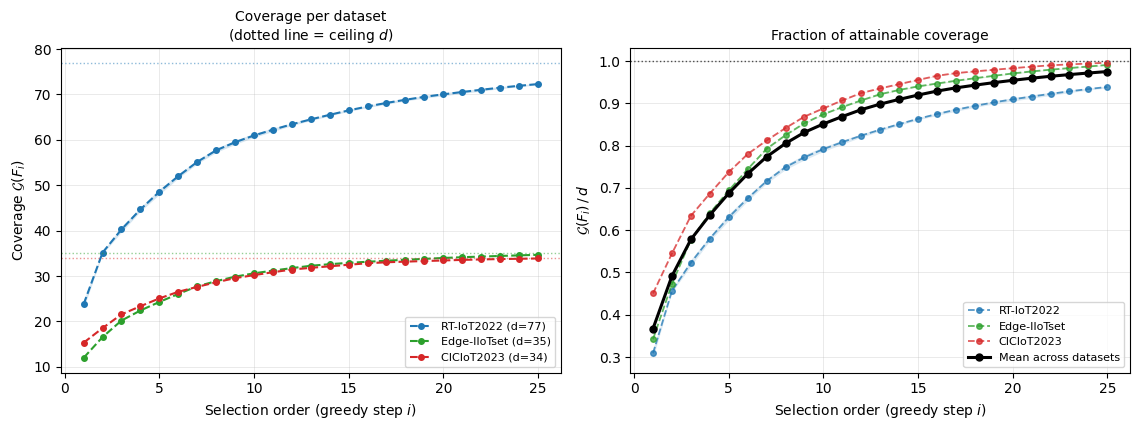

In [12]:
if not keys:
    print("nothing to plot")
else:
    COL = {"rt-iot": "#1f77b4", "edge-iiot": "#2ca02c", "cic-iot": "#d62728"}
    fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))

    for k in keys:
        b = per_ds[per_ds.dataset == k].sort_values("i")
        c = COL.get(k, None)
        x = b["i"].to_numpy()
        mu, sd = b["G_mean"].to_numpy(), np.nan_to_num(b["G_std"].to_numpy())
        ax[0].plot(x, mu, "o--", color=c, ms=4, lw=1.5, label=f"{meta[k]['name']} (d={meta[k]['d']})")
        ax[0].fill_between(x, mu - sd, mu + sd, color=c, alpha=0.18, lw=0)
        ax[0].axhline(meta[k]["d"], color=c, ls=":", lw=1, alpha=0.5)

        mu, sd = b["G_norm_mean"].to_numpy(), np.nan_to_num(b["G_norm_std"].to_numpy())
        ax[1].plot(x, mu, "o--", color=c, ms=4, lw=1.3, alpha=0.75, label=meta[k]["name"])
        ax[1].fill_between(x, mu - sd, mu + sd, color=c, alpha=0.15, lw=0)

    ax[1].plot(across["i"], across["Gn_mean"], "o-", color="black", ms=5, lw=2.2,
               label="Mean across datasets", zorder=5)
    ax[1].axhline(1.0, color="0.3", ls=":", lw=1)

    ax[0].set_xlabel("Selection order (greedy step $i$)")
    ax[0].set_ylabel(r"Coverage $\mathcal{G}(F_i)$")
    ax[0].set_title("Coverage per dataset\n(dotted line = ceiling $d$)", fontsize=10)
    ax[1].set_xlabel("Selection order (greedy step $i$)")
    ax[1].set_ylabel(r"$\mathcal{G}(F_i)\,/\,d$")
    ax[1].set_title("Fraction of attainable coverage", fontsize=10)
    for a in ax:
        a.grid(alpha=0.3, lw=0.6)
        a.legend(fontsize=8, loc="lower right")
        a.set_xticks(range(0, KMAX + 1, 5))
    fig.tight_layout()

    os.makedirs(OUT_DIR, exist_ok=True)
    for ext in ("png", "pdf"):
        p = os.path.join(OUT_DIR, f"cgfs_coverage_gain.{ext}")
        fig.savefig(p, dpi=300, bbox_inches="tight")
        print("wrote", p)
    plt.show()

wrote ./cgfs_marginal_gain.png
wrote ./cgfs_marginal_gain.pdf


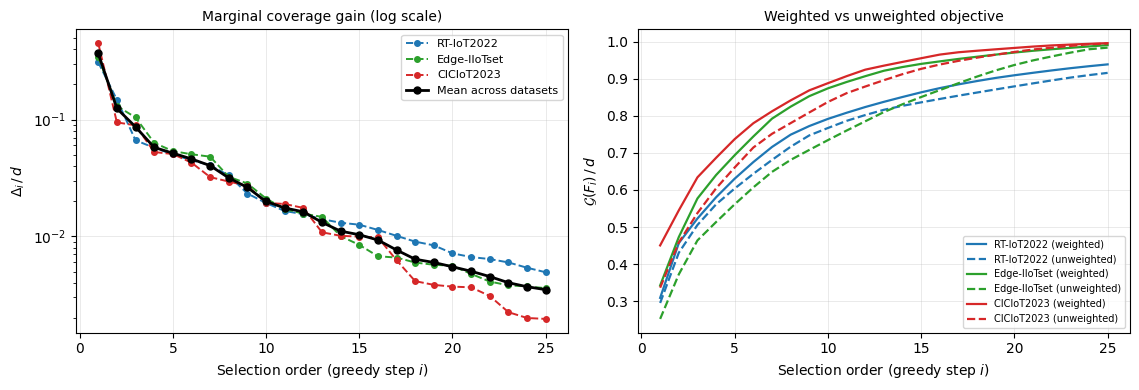

In [13]:
# Marginal gains, log scale: the decay rate is what the diminishing-returns
# argument in the paper appeals to.
if keys:
    fig2, ax2 = plt.subplots(1, 2, figsize=(11.5, 4.0))
    for k in keys:
        b = per_ds[per_ds.dataset == k].sort_values("i")
        ax2[0].plot(b["i"], b["delta_norm_mean"], "o--", color=COL.get(k),
                    ms=4, lw=1.4, label=meta[k]["name"])
    ax2[0].plot(across["i"], across["dG_mean"], "o-", color="black", ms=5, lw=2.0,
                label="Mean across datasets")
    ax2[0].set_yscale("log")
    ax2[0].set_xlabel("Selection order (greedy step $i$)")
    ax2[0].set_ylabel(r"$\Delta_i\,/\,d$")
    ax2[0].set_title("Marginal coverage gain (log scale)", fontsize=10)

    if INCLUDE_UNWEIGHTED:
        U = traj[traj.variant == "unweighted"]
        for k in keys:
            for v, ls, lab in ((W, "-", "weighted"), (U, "--", "unweighted")):
                b = (v[v.dataset == k].groupby("i")["G_norm"].mean().reset_index())
                ax2[1].plot(b["i"], b["G_norm"], ls, color=COL.get(k), lw=1.6,
                            label=f"{meta[k]['name']} ({lab})")
        ax2[1].set_xlabel("Selection order (greedy step $i$)")
        ax2[1].set_ylabel(r"$\mathcal{G}(F_i)\,/\,d$")
        ax2[1].set_title("Weighted vs unweighted objective", fontsize=10)
        ax2[1].legend(fontsize=7, loc="lower right")
    else:
        ax2[1].axis("off")

    ax2[0].legend(fontsize=8)
    for a in ax2:
        a.grid(alpha=0.3, lw=0.6)
    fig2.tight_layout()
    for ext in ("png", "pdf"):
        p = os.path.join(OUT_DIR, f"cgfs_marginal_gain.{ext}")
        fig2.savefig(p, dpi=300, bbox_inches="tight")
        print("wrote", p)
    plt.show()

## 11. Empirical approximation ratio

The worst-case guarantee for greedy maximisation of a monotone submodular
function is $\mathcal{G}(F_k) \ge (1 - 1/e)\,\mathrm{OPT}_k \approx 0.632\,
\mathrm{OPT}_k$. That bound is pessimistic on real data. Minoux's certificate
evaluated at the returned solution gives a data-dependent upper bound on
$\mathrm{OPT}_k$, and hence a lower bound on the ratio actually achieved, without
knowing the optimum.

In [14]:
if COMPUTE_ONLINE_BOUND:
    print(f"Greedy coverage against the data-dependent bound at k={KMAX}\n")
    print(f"{'Dataset':16s} {'seed':>5s} {'G(F_k)':>10s} {'UB(OPT_k)':>11s} {'ratio >=':>9s}")
    for k in keys:
        spec = DATASETS[k]
        X_all, y_raw, cols = load_dataset(spec, drop_leaky=DROP_LEAKY,
                                          base_sample=BASE_SAMPLE.get(k))
        y_all = LabelEncoder().fit_transform(y_raw)
        for s in SEEDS:
            r = trajectory(X_all, y_all, cols, s, KMAX, weighted=True, bound=True)
            print(f"{meta[k]['name']:16s} {s:5d} {r['G'][-1]:10.3f} "
                  f"{r['upper_bound']:11.3f} {r['ratio']:9.4f}")
    print("\nWorst-case theory guarantees 0.6321; the certificate above is the")
    print("ratio these runs provably attained, which is the number to quote.")

Greedy coverage against the data-dependent bound at k=25

Dataset           seed     G(F_k)   UB(OPT_k)  ratio >=
RT-IoT2022: 123,117 rows x 83 columns (leaky columns dropped: [])
  label-encoded columns : ['proto', 'service']
  non-finite/missing cells filled with 0 : 0
RT-IoT2022           0     72.480      77.102    0.9400
RT-IoT2022           1     72.240      77.205    0.9357
RT-IoT2022           2     72.150      77.312    0.9332
Edge-IIoTset: 157,800 rows x 49 columns (leaky columns dropped: ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.src.proto_ipv4', 'arp.dst.proto_ipv4', 'http.request.full_uri', 'http.file_data', 'http.request.uri.query', 'tcp.payload', 'tcp.options', 'mqtt.msg', 'dns.qry.name'])
  label-encoded columns : ['http.request.method', 'http.referer', 'http.request.version', 'tcp.srcport', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.protoname', 'mqtt.topic']
  non-finite/missing cells filled with 0 : 0
Edge-IIoTset         0     34.694      35.076    0.9891


## 12. Save

In [15]:
os.makedirs(OUT_DIR, exist_ok=True)
p_raw = os.path.join(OUT_DIR, "cgfs_coverage_trajectory_raw.csv")
p_ds  = os.path.join(OUT_DIR, "cgfs_coverage_per_dataset.csv")
p_avg = os.path.join(OUT_DIR, "cgfs_coverage_across_datasets.csv")
traj.to_csv(p_raw, index=False)
per_ds.to_csv(p_ds, index=False)
across.to_csv(p_avg, index=False)
for p in (p_raw, p_ds, p_avg):
    print("wrote", p)

lines = ["% Coverage gain of the CGFS greedy sequence.",
         "% Requires \\usepackage{booktabs}.",
         "\\begin{table}[!t]\\centering\\small",
         "\\caption{Weighted coverage $\\mathcal{G}(F_i)$ attained by the CGFS greedy "
         f"sequence, mean $\\pm$ standard deviation over {len(SEEDS)} seeds. The "
         "ceiling $d$ is the screened dimensionality, since $\\sum_j w_j = d$.}",
         "\\label{tab:coverage_gain}",
         "\\begin{tabular}{lc" + "c" * len(miles) + "}", "\\toprule",
         "Dataset & $d$ & " + " & ".join(f"$i={i}$" for i in miles) + " \\\\", "\\midrule"]
for k in keys:
    b = per_ds[per_ds.dataset == k].set_index("i")
    cellz = " & ".join(f"{b.loc[i, 'G_mean']:.2f}" for i in miles)
    lines.append(f"{meta[k]['name']} & {meta[k]['d']} & {cellz} \\\\")
lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}", ""]
p_tex = os.path.join(OUT_DIR, "cgfs_coverage_gain.tex")
open(p_tex, "w").write("\n".join(lines))
print("wrote", p_tex)

wrote ./cgfs_coverage_trajectory_raw.csv
wrote ./cgfs_coverage_per_dataset.csv
wrote ./cgfs_coverage_across_datasets.csv
wrote ./cgfs_coverage_gain.tex
